In [1]:
import os
import pandas as pd

In [2]:
data_path = "../data/raw/diabetic_data.csv"

In [3]:
df = pd.read_csv(data_path)

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

In [6]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [9]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [10]:
df['target']=(df['readmitted'] == '<30').astype(int)

In [11]:
df['target'].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [12]:
print(f"\nReadmission Rate: {df['target'].mean() * 100:.2f}%")


Readmission Rate: 11.16%


Only 11% is readmitted - shows a highly imbalance dataset

In [13]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [14]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,Down,No,No,No,No,No,Ch,Yes,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,Steady,No,No,No,No,No,No,Yes,NO,0
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,Down,No,No,No,No,No,Ch,Yes,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,Up,No,No,No,No,No,Ch,Yes,NO,0
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,NO,0


In [15]:
(df == '?').sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [16]:
columns_to_drop = ['weight', 'payer_code']
df = df.drop(columns=columns_to_drop)


In [17]:
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')

In [18]:
import numpy as np

In [19]:
df = df.replace('?', np.nan)

In [20]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

In [21]:
df['target'].value_counts(normalize=True)

target
0    0.888401
1    0.111599
Name: proportion, dtype: float64

Target Imbalance Percentage:
target
0    88.840084
1    11.159916
Name: proportion, dtype: float64


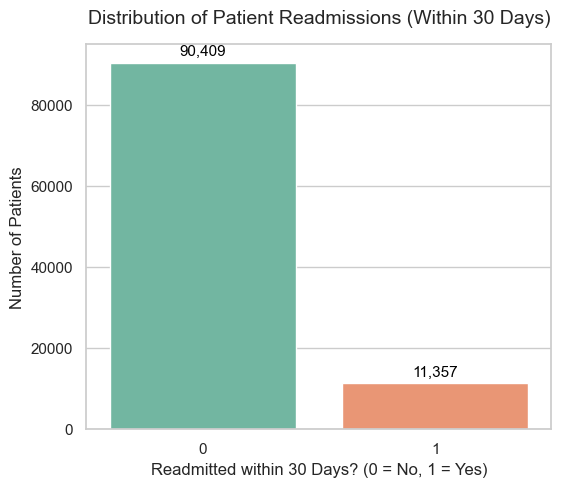

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Target Imbalance Percentage:")
print(df['target'].value_counts(normalize=True) * 100)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)

plt.title('Distribution of Patient Readmissions (Within 30 Days)', fontsize=14, pad=15)
plt.xlabel('Readmitted within 30 Days? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()

In [23]:
key_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses'
]

print("Numerical Columns Summary Statistics:")
df[key_cols].describe().T

Numerical Columns Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


In [24]:
outlier_shape = df[df['num_medications'] > 60].shape
print(f"Number of patients taking more than 60 medications: {outlier_shape[0]}")

Number of patients taking more than 60 medications: 97


In [25]:
df.groupby('target')[['number_inpatient','number_emergency','number_outpatient','time_in_hospital','num_medications']].mean()

,number_inpatient,number_emergency,number_outpatient,time_in_hospital,num_medications
target,,,,,
0,0.561648,0.177803,0.360871,4.349224,15.911137
1,1.224003,0.357313,0.436911,4.768249,16.903143


Correlation Matrix for Prior Utilization Features:


,number_outpatient,number_emergency,number_inpatient
number_outpatient,1.000000,0.091459,0.107338
number_emergency,0.091459,1.000000,0.266559
number_inpatient,0.107338,0.266559,1.000000


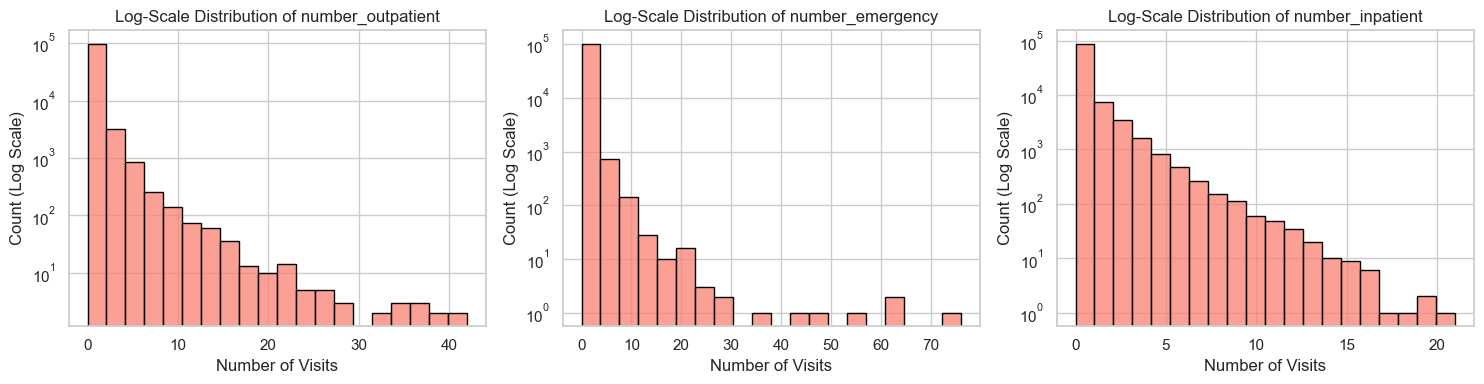

In [26]:
utilization_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']

print("Correlation Matrix for Prior Utilization Features:")
util_corr = df[utilization_cols].corr()
display(util_corr)

#Plot the zero-inflated distributions on a log scale
plt.figure(figsize=(15, 4))
for i, col in enumerate(utilization_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=col, bins=20, color='salmon', edgecolor='black')
    plt.yscale('log')  # Applies the log scale to the y-axis
    plt.title(f'Log-Scale Distribution of {col}')
    plt.xlabel('Number of Visits')
    plt.ylabel('Count (Log Scale)')

plt.tight_layout()
plt.show()

In [27]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [28]:
unique_per_column = {col: df[col].unique().tolist() for col in categorical_cols}
unique_per_column


{'race': ['Caucasian', 'AfricanAmerican', nan, 'Other', 'Asian', 'Hispanic'],
 'gender': ['Female', 'Male', 'Unknown/Invalid'],
 'age': ['[0-10)',
  '[10-20)',
  '[20-30)',
  '[30-40)',
  '[40-50)',
  '[50-60)',
  '[60-70)',
  '[70-80)',
  '[80-90)',
  '[90-100)'],
 'medical_specialty': ['Pediatrics-Endocrinology',
  'Unknown',
  'InternalMedicine',
  'Family/GeneralPractice',
  'Cardiology',
  'Surgery-General',
  'Orthopedics',
  'Gastroenterology',
  'Surgery-Cardiovascular/Thoracic',
  'Nephrology',
  'Orthopedics-Reconstructive',
  'Psychiatry',
  'Emergency/Trauma',
  'Pulmonology',
  'Surgery-Neuro',
  'Obsterics&Gynecology-GynecologicOnco',
  'ObstetricsandGynecology',
  'Pediatrics',
  'Hematology/Oncology',
  'Otolaryngology',
  'Surgery-Colon&Rectal',
  'Pediatrics-CriticalCare',
  'Endocrinology',
  'Urology',
  'Psychiatry-Child/Adolescent',
  'Pediatrics-Pulmonology',
  'Neurology',
  'Anesthesiology-Pediatric',
  'Radiology',
  'Pediatrics-Hematology-Oncology',
  'Psycho

In [29]:
df['discharge_disposition_id'].unique()   

array([25,  1,  3,  6,  2,  5, 11,  7, 10,  4, 14, 18,  8, 13, 12, 16, 17,
       22, 23,  9, 20, 15, 24, 28, 19, 27])

In [30]:
df['admission_type_id'].unique()   

array([6, 1, 2, 3, 4, 5, 8, 7])

In [31]:
df['admission_source_id'].unique()   

array([ 1,  7,  2,  4,  5,  6, 20,  3, 17,  8,  9, 14, 10, 22, 11, 25, 13])

In [32]:
def map_discharge_full(val):
    if val == 1: 
        return 'Home'
    elif val == 6: 
        return 'Home Health Care'
    # Grouping all medical facility transfer types together
    elif val in [2, 3, 4, 5, 7, 8, 9, 10, 12, 15, 16, 17, 22, 23, 24, 25, 27]: 
        return 'Transfer (Hospital/SNF)'
    # Grouping all terminal/end-of-life care together based on the paper's data
    elif val in [11, 13, 14, 19, 20, 21, 28]: 
        return 'Hospice/Expired'
    else: 
        return 'Other/Unknown'

def map_admission_type_full(val):
    if val == 1: return 'Emergency'
    elif val == 2: return 'Urgent'
    elif val == 3: return 'Elective'
    elif val == 4: return 'Newborn'
    else: return 'Other/Unknown'

def map_admission_source_full(val):
    if val == 7: 
        return 'Emergency Room'
    elif val in [1, 2, 3]: 
        return 'Referral'
    elif val in [4, 5, 6, 10, 22, 25]: 
        return 'Transfer (Hosp/Clinic)'
    else: 
        return 'Other/Unknown'

C:\Users\aadhi\AppData\Local\Temp\ipykernel_14912\3590987293.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
C:\Users\aadhi\AppData\Local\Temp\ipykernel_14912\3590987293.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
C:\Users\aadhi\AppData\Local\Temp\ipykernel_14912\3590987293.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')


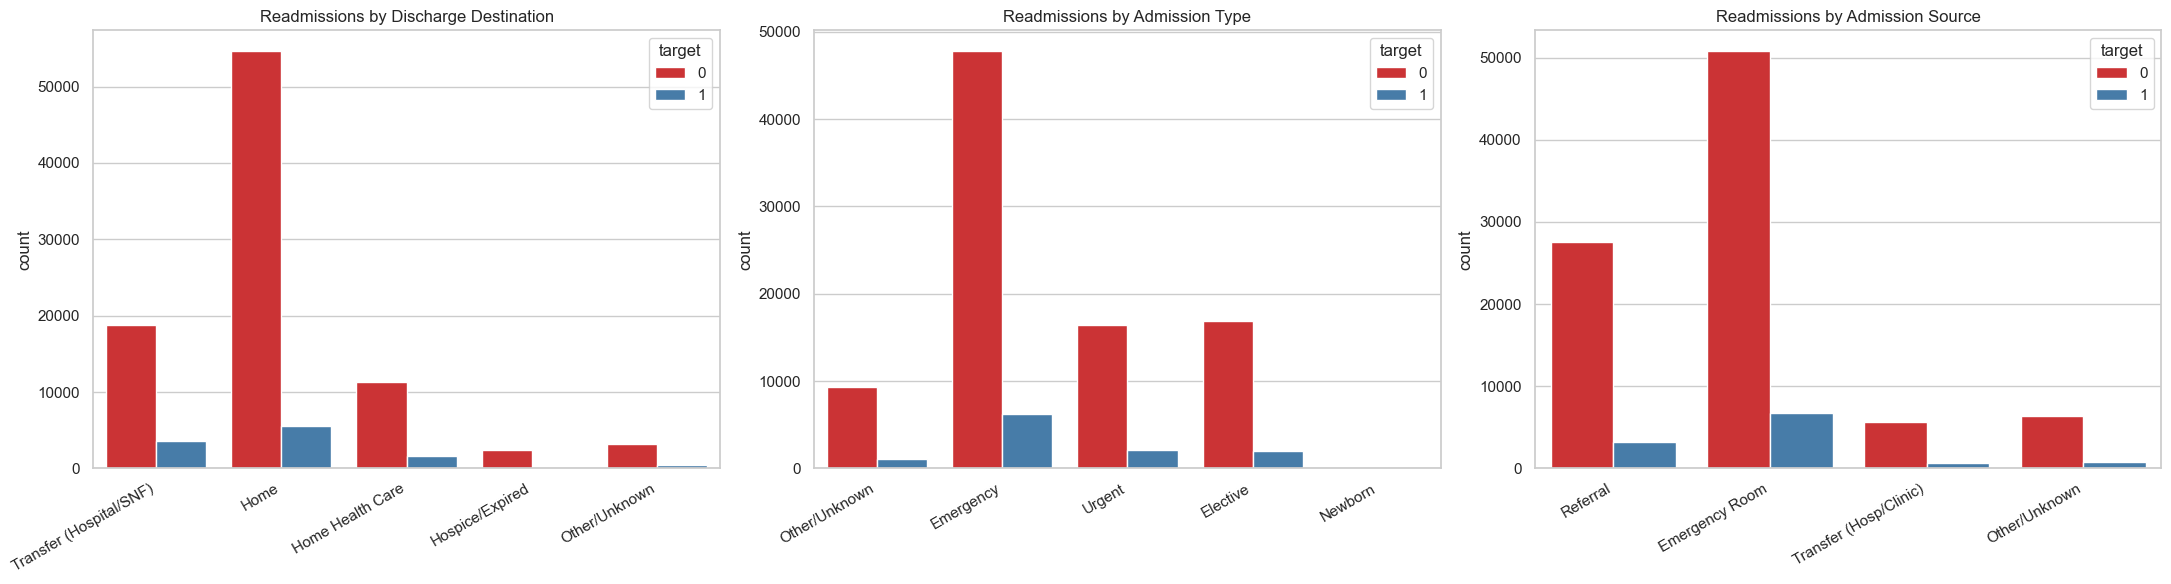

In [33]:
df['discharge_clean'] = df['discharge_disposition_id'].apply(map_discharge_full)
df['admission_type_clean'] = df['admission_type_id'].apply(map_admission_type_full)
df['admission_source_clean'] = df['admission_source_id'].apply(map_admission_source_full)

#Plot all 3 High-Signal Categorical features side by side
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Chart 1: Discharge Destination
sns.countplot(data=df, x='discharge_clean', hue='target', palette='Set1', ax=axes[0])
axes[0].set_title('Readmissions by Discharge Destination', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_xlabel('')

# Chart 2: Admission Type
sns.countplot(data=df, x='admission_type_clean', hue='target', palette='Set1', ax=axes[1])
axes[1].set_title('Readmissions by Admission Type', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_xlabel('')

# Chart 3: Admission Source
sns.countplot(data=df, x='admission_source_clean', hue='target', palette='Set1', ax=axes[2])
axes[2].set_title('Readmissions by Admission Source', fontsize=12)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

In [34]:
df['insulin'].value_counts()

insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

In [35]:
print("Readmission Rate by Insulin Status:")
insulin_rates = df.groupby('insulin')['target'].mean() * 100
for status, rate in insulin_rates.items():
    print(f"  Insulin {status}: {rate:.2f}% readmitted")

Readmission Rate by Insulin Status:
  Insulin Down: 13.90% readmitted
  Insulin No: 10.04% readmitted
  Insulin Steady: 11.13% readmitted
  Insulin Up: 12.99% readmitted


The fact that Insulin Down and Insulin Up have significantly higher readmission rates confirms that dosage volatility is a proxy for patient instability. If a medical team is actively fighting to stabilize a patient's blood sugar during their stay—either because it's spiking too high or crashing too low—that patient is structurally more fragile and far more likely to end up back in the hospital within 30 days.

In [36]:
print("Readmission Rate by General Medication Flags:")
change_rate = df.groupby('change')['target'].mean() * 100
med_rate = df.groupby('diabetesMed')['target'].mean() * 100

print(f"  No Med Change: {change_rate.get('No', 0):.2f}% vs Change Occurred: {change_rate.get('Ch', 0):.2f}%")
print(f"  No Diabetes Med Prescribed: {med_rate.get('No', 0):.2f}% vs Med Prescribed: {med_rate.get('Yes', 0):.2f}%")

Readmission Rate by General Medication Flags:
  No Med Change: 10.59% vs Change Occurred: 11.82%
  No Diabetes Med Prescribed: 9.60% vs Med Prescribed: 11.63%


Change Occurred (11.82%) vs No Med Change (10.59%): Any alteration to any diabetes medication indicates that the initial treatment plan wasn't working, flagging an active, shifting clinical situation.

Med Prescribed (11.63%) vs No Diabetes Med Prescribed (9.60%): Patients who don't even require diabetes medication during their stay have a noticeably lower readmission profile.

In [37]:
df['diag_1'].value_counts().head(20)

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

In [38]:
def map_icd9_to_category(code):
    if pd.isna(code) or str(code).strip() == '?' or str(code).strip() == '':
        return 'Other'
    
    code_str = str(code).strip()
    
    # 1. Direct check for Diabetes (starts with 250)
    if code_str.startswith('250'):
        return 'Diabetes'
        
    # 2. Handle codes starting with letters (V or E codes are external/supplemental causes)
    if not code_str[0].isdigit():
        return 'Other'
        
    # 3. Extract the numeric prefix (before the decimal point) to check standard ranges
    try:
        prefix = int(float(code_str.split('.')[0]))
    except ValueError:
        return 'Other'
        
    # 4. Check ranges based on Table 2 of the research paper
    if 390 <= prefix <= 459 or prefix == 785:
        return 'Circulatory'
    elif 460 <= prefix <= 519 or prefix == 786:
        return 'Respiratory'
    elif 520 <= prefix <= 579 or prefix == 787:
        return 'Digestive'
    elif 140 <= prefix <= 239:
        return 'Neoplasms'
    elif 580 <= prefix <= 629 or prefix == 788:
        return 'Genitourinary'
    elif 710 <= prefix <= 739:
        return 'Musculoskeletal'
    elif 800 <= prefix <= 999:
        return 'Injury'
    else:
        return 'Other'

# Apply the mapping function to all three diagnosis columns
df['diag_1_clean'] = df['diag_1'].apply(map_icd9_to_category)
df['diag_2_clean'] = df['diag_2'].apply(map_icd9_to_category)
df['diag_3_clean'] = df['diag_3'].apply(map_icd9_to_category)

# Verify the transformation on your primary diagnosis
print("Distribution of Cleaned Primary Diagnoses (diag_1_clean):")
print(df['diag_1_clean'].value_counts())
print("\nPercentage Breakdown:")
print(df['diag_1_clean'].value_counts(normalize=True) * 100)

Distribution of Cleaned Primary Diagnoses (diag_1_clean):
diag_1_clean
Circulatory        30437
Other              18193
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Name: count, dtype: int64

Percentage Breakdown:
diag_1_clean
Circulatory        29.908810
Other              17.877287
Respiratory        14.172710
Digestive           9.310575
Diabetes            8.605035
Injury              6.852976
Genitourinary       5.028202
Musculoskeletal     4.870979
Neoplasms           3.373425
Name: proportion, dtype: float64


In [40]:
print("Value counts for examide:")
print(df['examide'].value_counts())
print("\nValue counts for citoglipton:")
print(df['citoglipton'].value_counts())

Value counts for examide:
examide
No    101766
Name: count, dtype: int64

Value counts for citoglipton:
citoglipton
No    101766
Name: count, dtype: int64


In [41]:
print("Columns with the lowest number of unique values:")
print(df.nunique().sort_values().head(10))

Columns with the lowest number of unique values:
examide                     1
citoglipton                 1
acetohexamide               2
tolbutamide                 2
diabetesMed                 2
troglitazone                2
metformin-rosiglitazone     2
metformin-pioglitazone      2
glipizide-metformin         2
glimepiride-pioglitazone    2
dtype: int64


In [42]:
columns_to_drop= ['encounter_id', 'patient_nbr', 'examide', 'citoglipton']

In [43]:
columns_present = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_present)

print(f"Successfully dropped columns: {columns_present}")
print(f"Current remaining dataframe shape: {df.shape}")

Successfully dropped columns: ['encounter_id', 'patient_nbr', 'examide', 'citoglipton']
Current remaining dataframe shape: (101766, 51)


In [46]:
df_raw = pd.read_csv(data_path)

In [48]:
df_raw['patient_nbr'].value_counts()

patient_nbr
88785891     40
43140906     28
88227540     23
23199021     23
1660293      23
             ..
3327282       1
98427861      1
92519352      1
101002446     1
104672268     1
Name: count, Length: 71518, dtype: int64

In [47]:
#Get the row indices of the first occurrence for each patient
first_encounter_indices = df_raw.drop_duplicates(subset='patient_nbr', keep='first').index

#Filter your already-cleaned df using these exact matching index positions
df = df.loc[first_encounter_indices]

#Verify the results
print(f"Indices to keep calculated from df_raw: {len(first_encounter_indices):,}")
print(f"Final deduplicated cleaned dataframe shape: {df.shape}")

Indices to keep calculated from df_raw: 71,518
Final deduplicated cleaned dataframe shape: (71518, 51)


## 📊 Final EDA Summary & Preprocessing Blueprint

### 1. Target Class Imbalance Severity
* **The Reality:** We are dealing with a heavily imbalanced dataset where roughly **89%** of patients are not readmitted within 30 days, and only **11%** are readmitted (`target = 1`).
* **Modeling Impact:** Standard accuracy is a trap here. A dummy model predicting "no readmission" every time would achieve 89% accuracy while catching zero high-risk patients. We must track **Recall** and **F1-Score**, and utilize **SMOTE** (Synthetic Minority Over-sampling Technique) during training to balance the classes fairly.

### 2. Top High-Signal Features Identified
Through correlation matrices, grouping analysis, and data visualizations, the following 5–6 features stand out as our strongest predictive signals:
1. **`number_inpatient`**: Our absolute strongest predictor. [cite_start]Patients with prior inpatient stays in the preceding year have a readmission rate that more than doubles (jumping from an average of 0.56 to 1.22 visits)[cite: 149].
2. **`discharge_disposition_id`**: Patients discharged to *Home Health Care* or *Transferred* to other medical facilities (SNFs) show significantly higher proportional readmission rates than those discharged straight *Home*.
3. **`number_emergency` & `number_outpatient`**: Heavily zero-inflated but highly predictive. Frequent flyers in the emergency room drastically elevate readmission probability.
4. **`insulin` (and overall `change`)**: Patients experiencing medication volatility (*Insulin Up* at 12.99% or *Insulin Down* at 13.90%) have noticeably higher readmission rates than those kept *Steady* (11.13%), proving dosage instability mirrors physical instability.
5. **`time_in_hospital` & `number_diagnoses`**: Longer stays and higher comorbidity (more recorded concurrent conditions) directly correlate with fragile discharge profiles.

### 3. Final Pipeline Preprocessing Decisions
To prepare this data for a clean machine learning input tomorrow, our script must execute the following actions:
* **Row Pruning (Hospice/Expired):** Filter out the 1,534 patients discharged to hospice or who passed away (`discharge_clean == 'Hospice/Expired'`) because they are clinically ineligible for readmission, matching the original paper's design[cite: 96, 151].
* **Column Dropping:** Permanently drop completely uninformative, zero-variance features (`examide`, `citoglipton`) along with row identifiers (`encounter_id`, `patient_nbr`).
* **Feature Engineering (ICD-9 Bucketing):** Group the hundreds of raw `diag_1`, `diag_2`, and `diag_3` strings into the 9 clinical categories aligned with the research paper (*Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other*)[cite: 129].
* **Outlier Capping:** Clip extreme numerical anomalies, such as capping `num_medications` at 60, so the 97 extreme cases don't skew model weightings.
* [cite_start]**Missing Value (`NaN`) Strategy:** Treat the `?` in `medical_specialty` as its own valid `"Unknown"` category string, while routing minor remaining missing rows into standard imputers[cite: 92].
* **Categorical Encoding:** Apply One-Hot Encoding to our newly engineered, cleaned structural text buckets before splitting the data.